In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import shap
from mapie.classification import SplitConformalClassifier

In [2]:
df = pd.read_csv("alzheimers_disease_data.csv")
df.head()
df.isna().sum()

PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTasks    0
Forgetfu

In [3]:
df.shape
df.isna().sum()
df.info()
df.describe()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

np.int64(0)

In [ ]:
# Select features for the interactive demo
demo_features = [
    "MMSE",
    "FunctionalAssessment",
    "ADL",
    "MemoryComplaints",
    "BehavioralProblems"
]

X_demo = df[demo_features]
y_demo = df["Diagnosis"]

X_demo.head()

,MMSE,FunctionalAssessment,ADL,MemoryComplaints,BehavioralProblems
0,21.463532,6.518877,1.725883,0,0
1,20.613267,7.118696,2.592424,0,0
2,7.356249,5.895077,7.119548,0,0
3,13.991127,8.965106,6.481226,0,1
4,13.517609,6.045039,0.014691,0,0


In [ ]:
# Split the demo dataset
X_train_demo, X_test_demo, y_train_demo, y_test_demo = train_test_split(
    X_demo,
    y_demo,
    test_size=0.2,
    random_state=42,
    stratify=y_demo
)

In [17]:
# Train the simplified Random Forest model

rf_demo = RandomForestClassifier(
    n_estimators=100,
    random_state=42 
)

rf_demo.fit(X_train_demo, y_train_demo)

# Evaluate the demo model

y_pred_demo = rf_demo.predict(X_test_demo)

print("Demo Model Accuracy:", accuracy_score(y_test_demo, y_pred_demo))
print()
print(classification_report(y_test_demo, y_pred_demo))

Demo Model Accuracy: 0.9441860465116279

              precision    recall  f1-score   support

           0       0.95      0.96      0.96       278
           1       0.93      0.91      0.92       152

    accuracy                           0.94       430
   macro avg       0.94      0.94      0.94       430
weighted avg       0.94      0.94      0.94       430



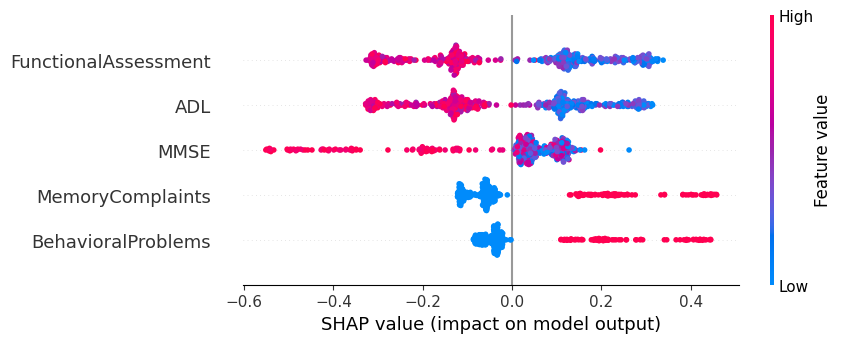

In [5]:
# Explain the demo model using SHAP

explainer_demo = shap.TreeExplainer(rf_demo)
shap_values_demo = explainer_demo(X_test_demo)

shap.plots.beeswarm(
    shap_values_demo[:, :, 1],
    max_display=5
)

In [ ]:
# Split the demo training set into training and calibration sets

X_train_demo_mapie, X_calib_demo, y_train_demo_mapie, y_calib_demo = train_test_split(
    X_train_demo,
    y_train_demo,
    test_size=0.2,
    random_state=42,
    stratify=y_train_demo
)

# Train the demo Random Forest for MAPIE

rf_demo_mapie = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_demo_mapie.fit(X_train_demo_mapie, y_train_demo_mapie)

Prediction shape: (430,)
Prediction set shape: (430, 2, 1)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Create a conformal classifier for the demo model

mapie_demo = SplitConformalClassifier(
    estimator=rf_demo_mapie,
    confidence_level=0.90,
    conformity_score="lac",
    prefit=True
)

mapie_demo.conformalize(X_calib_demo, y_calib_demo)

# Generate demo predictions and prediction sets

y_pred_demo_mapie, y_pred_set_demo = mapie_demo.predict_set(X_test_demo)

print("Prediction shape:", y_pred_demo_mapie.shape)
print("Prediction set shape:", y_pred_set_demo.shape)

In [ ]:
# Remove the confidence-level dimension

pred_set_demo = y_pred_set_demo[:, :, 0]


# Calculate prediction set sizes

set_sizes_demo = pred_set_demo.sum(axis=1)

print("Average prediction set size:", set_sizes_demo.mean())
print("Number of singleton sets:", (set_sizes_demo == 1).sum())
print("Number of ambiguous sets {0,1}:", (set_sizes_demo == 2).sum())
print("Number of empty sets:", (set_sizes_demo == 0).sum())


Average prediction set size: 0.9465116279069767
Number of singleton sets: 407
Number of ambiguous sets {0,1}: 0
Number of empty sets: 23
Empirical coverage: 0.9023255813953488


In [ ]:
# Calculate empirical coverage

y_test_demo_array = y_test_demo.to_numpy()

covered_demo = pred_set_demo[
    np.arange(len(y_test_demo_array)),
    y_test_demo_array
]

coverage_demo = covered_demo.mean()

print("Empirical coverage:", coverage_demo)

In [14]:
# Import model persistence tool
import joblib

# Save the trained demo model
joblib.dump(rf_demo_mapie, "rf_demo_model.pkl")

# Save calibration data for MAPIE
joblib.dump(X_calib_demo, "X_calib_demo.pkl")
joblib.dump(y_calib_demo, "y_calib_demo.pkl")

['y_calib_demo.pkl']